In [1]:
import qiskit
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

print("Qiskit Version:", qiskit.__version__)
simulator = AerSimulator()
print(simulator)


Qiskit Version: 2.5.1
AerSimulator('aer_simulator')


H0: Source is unbiased, P(1) = 0.5
H1: Source is biased, P(1) != 0.5

Quantum source:
Counts: {'0': 523, '1': 477}
Z-score: -1.455

Biased pseudo-random source:
Number of ones: 351
Estimated P(1): 0.351
Z-score: -9.424

Decision rule: Reject H0 if |Z| > 1.96


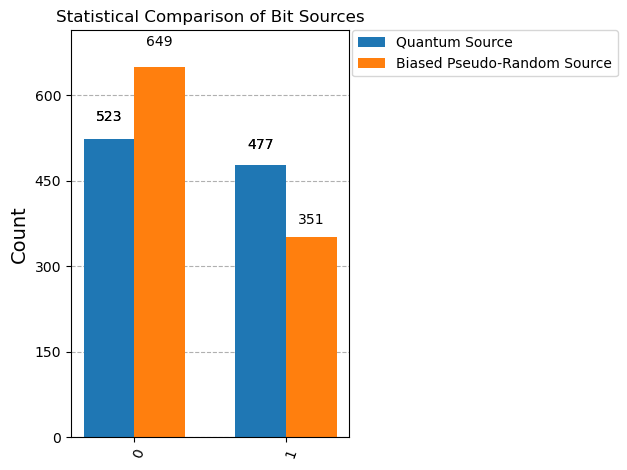

In [2]:
shots = 1000

# Quantum random bits
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)

quantum_counts = simulator.run(qc, shots=shots).result().get_counts()
quantum_ones = quantum_counts.get("1", 0)

# Deliberately biased pseudo-random source
rng = np.random.default_rng(seed=42)
biased_bits = rng.choice([0, 1], size=shots, p=[0.65, 0.35])
classical_ones = int(np.sum(biased_bits))

# Test H0: P(1) = 0.5
expected = shots * 0.5
std = np.sqrt(shots * 0.25)

z_quantum = (quantum_ones - expected) / std
z_classical = (classical_ones - expected) / std

print("H0: Source is unbiased, P(1) = 0.5")
print("H1: Source is biased, P(1) != 0.5")

print("\nQuantum source:")
print("Counts:", quantum_counts)
print(f"Z-score: {z_quantum:.3f}")

print("\nBiased pseudo-random source:")
print(f"Number of ones: {classical_ones}")
print(f"Estimated P(1): {classical_ones/shots:.3f}")
print(f"Z-score: {z_classical:.3f}")

critical_value = 1.96
print("\nDecision rule: Reject H0 if |Z| > 1.96")

plot_histogram(
    [quantum_counts, {"0": shots-classical_ones, "1": classical_ones}],
    legend=["Quantum Source", "Biased Pseudo-Random Source"],
    title="Statistical Comparison of Bit Sources"
)
